# Getting started with beamforming

In this Notebook, we propose to perform a beamforming operation on signals from a Megamicros database using the `Beamformer` class. 

## Beamforming with H5 file

In this example we compute the beamforming on signals comming from a Megamicros antenna saved in a H5 file.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython import display

from megamicros_tools.log import log
from megamicros.core.h5 import MemsArrayH5
from megamicros.data import MuAudio, generate_moovie
from megamicros.bmf import Beamformer, BeamformerFDAS
from megamicros.core.base import MemsArray

# Set a moderate level to avoid too much display (use "INFO" or "DEBUG" for more details).
log.setLevel( "INFO" )

# Choose a directory where some H5 files are stored
DIRECTORY = '/Users/brunogas/Data/comptine/poc1/'

# Choose a H5 file
FILENAME = DIRECTORY + 'muh5-20240529-102428.h5'

## Geting signal from H5 file

In [2]:
# Define the antenna
antenna = MemsArrayH5( 
    filename=FILENAME
)

print( f"Sampling frequency: {antenna.sampling_frequency}Hz" )
print( f"Available MEMs number: {antenna.available_mems_number}" )
print( f"Whether counter is available or not: {antenna.counter}" )

2024-07-07 00:12:49,544 [INFO]:  .Install MemsArrayH5 settings
2024-07-07 00:12:49,544 [INFO]:  .Created a new antenna
2024-07-07 00:12:49,546 [INFO]:  .Found /Users/brunogas/Data/comptine/poc1/muh5-20240529-102428.h5 MuH5 file
2024-07-07 00:12:49,548 [INFO]:  .Set 32 available MEMs numbered from 0 to 31
2024-07-07 00:12:49,549 [INFO]:  .No analogic channels available


Sampling frequency: 20000.0Hz
Available MEMs number: 32
Whether counter is available or not: True


In [ ]:
# Remove counter
antenna.unsetCounterSkip()

# Activate MEMS 0 and 1 and get channels values
antenna.setActiveMems( (0, 1,) )
sound = antenna.get() << 8

# Display the sound
display.Audio( sound, rate=antenna.sampling_frequency )

### Init the beamformer

In [9]:
# Define antenna geometry
mems_number = 32
antenna_radius = 0.25
antenna_thickness = 0.0
antenna_angle_offset = 2 * np.pi / mems_number / 2

mems_position = np.array( MemsArray.Geometry.Circle( points_number=mems_number, radius=antenna_radius, height=antenna_thickness, angle_offset=antenna_angle_offset, clockwise=True ) )

# Define antenna focal
focal_plan_width = 5.72
focal_plan_depth = 7.6
focal_depth = 1.9
focal_plan_width_sampling = 41
focal_plan_depth_sampling = 41

locations = np.array( MemsArray.Geometry.HorizontalPlan( focal_plan_width, focal_plan_depth, -focal_depth, focal_plan_width_sampling, focal_plan_depth_sampling ) )

# Create the beamformer
bmf = BeamformerFDAS( 
    mems_position = mems_position,
    locations = locations,
    sampling_frequency = antenna.sampling_frequency,
    frame_length = antenna.frame_length,
)


2024-07-07 00:20:37,352 [INFO]:  .Set beamformer on a 32 MEMs antenna
2024-07-07 00:20:37,354 [INFO]:  .Set beamformer sampling frequency to 20000.0 Hz
2024-07-07 00:20:37,354 [INFO]:  .Set 1681 beamforming locations
2024-07-07 00:20:37,355 [INFO]:  .Set beamformer frame length to 512 Hz
2024-07-07 00:20:37,355 [INFO]:  .Set beamformer FFT window size to 512 samples
2024-07-07 00:20:37,356 [INFO]:  .BeamformerFDAS Initilization:
2024-07-07 00:20:37,356 [INFO]:   > Found antenna with 32 MEMs microphones
2024-07-07 00:20:37,357 [INFO]:   > FFT window size is 512 samples
2024-07-07 00:20:37,357 [INFO]:   > Time range: [0, 0.02555] s
2024-07-07 00:20:37,357 [INFO]:   > Sampling frequency: 20000.0 Hz
2024-07-07 00:20:37,358 [INFO]:   > Frequency range: [0, 10000.0] Hz (257 beams)
2024-07-07 00:20:37,358 [INFO]:   > frequency step: 38.91 Hz
2024-07-07 00:20:37,359 [INFO]:   > frequency bandwidth: [0.00, 10000.00] Hz
2024-07-07 00:20:37,359 [INFO]:   > frequency bandwidth indexes: [0, 256] ( 

### Plot antenna form

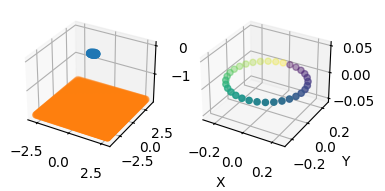

In [10]:
fig = plt.figure()
ax = fig.add_subplot( 131, projection='3d' )
ax.scatter( mems_position[:,0], mems_position[:,1], mems_position[:,2] )
ax.scatter( locations[:,0], locations[:,1], locations[:,2] )
ax = fig.add_subplot( 132, projection='3d' )

ax.set_xlabel( 'X' )
ax.set_ylabel( 'Y' )
ax.scatter( mems_position[:,0], mems_position[:,1], mems_position[:,2], c=np.arange(32) )


### Compute beamforming

In [11]:
antenna.run(
    mems = antenna.available_mems,
    duration=1,
    counter_skip = True,
    frame_length=512,
)

imgs = []
for data in antenna:
    BFE = bmf.compute( data )
    imgs.append( np.reshape(BFE, (focal_plan_depth_sampling, focal_plan_width_sampling) ) )

generate_moovie( 
    imgs, 
    rate=antenna.sampling_frequency/antenna.frame_length,
    sound=sound.astype( np.float32 ).T,
    sampling_frequency=antenna.sampling_frequency,
    norm=None,
    cleanup=True
)


2024-07-07 00:20:44,554 [INFO]:  .Starting run execution
2024-07-07 00:20:44,555 [INFO]:  .Install MemsArray settings
2024-07-07 00:20:44,556 [INFO]:  .32 MEMs were activated among 0 to 31 available MEMs
2024-07-07 00:20:44,556 [INFO]:  .Install MemsArrayH5 settings
2024-07-07 00:20:44,556 [INFO]:  .Pre-execution checks for MemsArray object
2024-07-07 00:20:44,557 [INFO]:  .Pre-execution checks for MemsArrayH5 object
2024-07-07 00:20:44,557 [INFO]:  .Perform a 1s run loop
2024-07-07 00:20:44,558 [INFO]:  .Frame length: 512 samples (chunk size: 65536 Bytes)
2024-07-07 00:20:44,558 [INFO]:  .Sampling frequency: 20000.0 Hz
2024-07-07 00:20:44,558 [INFO]:  .Active MEMs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
2024-07-07 00:20:44,558 [INFO]:  .Active analogic channels: []
2024-07-07 00:20:44,559 [INFO]:  .Whether counter is active: True
2024-07-07 00:20:44,559 [INFO]:  .Skipping counter: True
2024-07-07 00:20:44,

BFE_max_index= 1648
BFE_max_position= [-1.74390244  3.61463415 -1.9       ]
shape= (480, 640, 4)


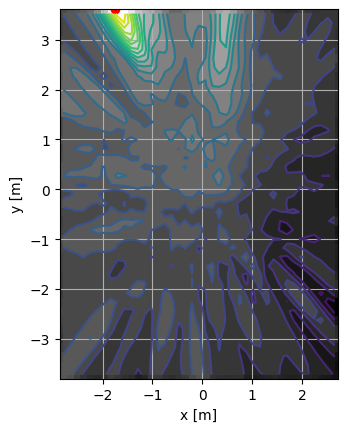

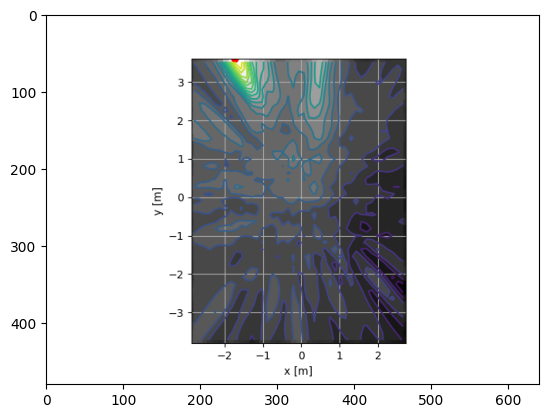

In [15]:
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

fig2 = plt.figure()
ax = fig2.add_subplot(111)
n_x = focal_plan_width_sampling
n_y = focal_plan_depth_sampling
BFEimg = np.reshape(BFE, (n_y, n_x) )
BFE_max_index = np.argmax( BFE )
BFE_max_position = locations[BFE_max_index,:]
XM = BFE_max_position[0]
YM = BFE_max_position[1]
print( 'BFE_max_index=', BFE_max_index)
print( 'BFE_max_position=', BFE_max_position)
xs = np.arange( -focal_plan_width/2, +focal_plan_width/2, focal_plan_width/n_x )
ys = np.arange( -focal_plan_depth/2, +focal_plan_depth/2, focal_plan_depth/n_y )
ax.imshow( BFEimg, extent=[ xs[0], xs[-1], ys[-1], ys[0] ], cmap='Greys_r', origin='upper')
ax.contourf( BFEimg, 20, extent=[ xs[0], xs[-1], ys[-1], ys[0] ], cmap='Greys_r', origin='upper' )
ax.contour( BFEimg, 20, extent=[ xs[0], xs[-1], ys[-1], ys[0] ], origin='upper' )
ax.scatter( XM, YM, c='r' )
ax.grid( True )
ax.set_aspect('equal')
ax.set_xlabel( 'x [m]' )
ax.set_ylabel( 'y [m]' )
ax.invert_yaxis()

canvas = FigureCanvas( fig2 )
canvas.draw()
img_array = np.array(canvas.buffer_rgba())
print( 'shape=', img_array.shape )

fig3 = plt.figure()
ax = fig3.add_subplot(111)
ax.imshow( img_array )

# fig2.savefig('ma_figure.png')

## Beamforming on database files

* This part will be removed in the futur

The antenna is physically defined in a file containing the relative coordinates of the microphones, the set of available MEMs and the activated MEMs:
```
antenna = { 
    'positions': np.ndarray( (mems_number, 3) ),
    'available_mems': [0, 1, ...],
    'mems': [0, 1, ...]
}
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython import display

from megamicros_tools.log import log
from megamicros.core.mu import Megamicros
from megamicros_aidb.query import AidbSession
from megamicros.data import MuAudio, generate_moovie
from megamicros.core.base import MemsArray
from megamicros.bmf import Beamformer

log.setLevel( "INFO" )

## Getting signal from DB

In [ ]:
# Available labels
LABEL_SOW_FEEDING_CALL = 18
LABEL_PIGLET_SQUEALS = 15
LABEL_SOW_GRUNT_NERVOUS = 16
LABEL_ROOM_NOISE = 29
LABEL_SOW_GRUNT = 8
LABEL_SOW_GRUNT_MODSTRESS  = 1
LABEL_SOW_SCREAMS = 3
LABEL_PIGLET_SQUEALS_2 = 5

# choose label, file and sequence in file:
LABEL_ID = LABEL_SOW_FEEDING_CALL
FILE_ID = 8692          # 5838 (1), 7135 (1), 6860(3), 6560(1)
SEQUENCE_ID = 0         

with AidbSession(
    dbhost='http://dbwelfare.biimea.io/',
    login='ailab',
    email='bruno.gas@biimea.com',
    password='#T;uZnQ5UJ_JC~&' ) as session:
        signal: MuAudio = session.load_labelized( 
            sourcefile_id=FILE_ID, 
            label_id=LABEL_ID, 
            limit=100,  
            channels=list( np.arange( 32 ) + 1 ) 
        )[SEQUENCE_ID]

# get infos
LABEL_TXT = signal.label
CHANNELS_NUMBER = signal.channels_number
SAMPLES_NUMBER = signal.samples_number
SAMPLING_FREQUENCY = signal.sampling_frequency

print( f"Some informations about the signal loaded:" )
print( f" > label={LABEL_TXT}" )
print( f" > channels_number={CHANNELS_NUMBER}" )
print( f" > samples_number={SAMPLES_NUMBER}" )
print( f" > sampling_frequency={SAMPLING_FREQUENCY}" )

In [ ]:
# Play sound using channel 0 and 1
left = np.array( signal.channel(0) )
right = np.array( signal.channel(1) )
sound = np.array( [left, right] ).T

display.Audio( sound, rate=SAMPLING_FREQUENCY )

## Set the beamformer

In [ ]:
FRAME_LENGTH = 1024
AREA = [12, 14, 0.01]
AREA_QUANTIZATION = [4, 4, 1/0.01]

# Get the antenna physical description
antenna = np.load ('Antenna-square-JetsonNano-0001.npy', allow_pickle=True )
mems_position = antenna.item().get("positions")

# Create the beamformer
bmf = Beamformer( 
    mems_position = mems_position,
    sampling_frequency = SAMPLING_FREQUENCY,
    window_size = FRAME_LENGTH,    
    area = AREA,
    area_quantization = AREA_QUANTIZATION
)

# Move the antenna in the right place:
bmf.moveArea( [0, 0, -2] )

# Limit the frequency bandwidth for BF computing
bmf.setBandWidth( [200, 2000], unit="frequency" )

# Init the beamformer
bmf.init()

# print area locations and antenna 
space_locations = bmf.getLocations()
mems_location = bmf.getMems()
nx, ny, nz = bmf.getLocationsNumber()

fig = plt.figure()
ax = fig.add_subplot( 121, projection='3d' )
ax.scatter( space_locations[:,0], space_locations[:,1], space_locations[:,2] )
ax.scatter( mems_location[:,0], mems_location[:,1], mems_location[:,2], marker='^' )
ax = fig.add_subplot( 122, projection='3d' )
ax.scatter( mems_location[:,0], mems_location[:,1], mems_location[:,2], marker='^' )
fig.show()


## Compute preformed channels 

In [ ]:
# Get the whole 32 channels signal as a numpy.ndarray
signal32 = signal().T

# Check if some available mems have not been activated
# Remove from signal if any
mems = antenna.item().get('mems')
available_mems = antenna.item().get('available_mems')
if False in np.isin( available_mems, mems ):
    mask = list( np.invert( np.logical_not( np.isin( available_mems, mems ) ) ) )
    signal32 = signal32[:,mask]

FRAMES_NUMBER = SAMPLES_NUMBER // FRAME_LENGTH - 1

print( f"{FRAMES_NUMBER} frames of {FRAME_LENGTH} samples to perform... " )


imgs = []
for i in range( FRAMES_NUMBER ):
    bf = bmf.beamform( signal32[i*FRAME_LENGTH:(i+1)*FRAME_LENGTH,:] )
    imgs.append( np.reshape( bf, (nx, ny) ) )

### Make video

In [ ]:
generate_moovie( 
    imgs, 
    rate=SAMPLING_FREQUENCY/FRAME_LENGTH,
    sound=sound.astype( np.float32 ).T,
    sampling_frequency=SAMPLING_FREQUENCY,
    norm=None,
    extent=( 0, AREA[0], 0, AREA[1] ),
    cleanup=True
)